# Generate functions to run simulation.
- Specify parameters (*Params*) values
- Generate a simulation object using setup functions.

1. Preamble: load packages and run necessary scripts.

In [1]:
using Random
using Plots
using Distributions
using CSV
using Tables
using DataFrames
using StatsPlots
using StatsBase
push!(LOAD_PATH, pwd()); 

Call input code files:
-  Include frequency weights based on Colombian income distribution
-  Setup

In [2]:
include("income_distribution.jl");
include("setup.jl");

2. Define a function to run simulation:
- Create empty vectors for counts of migrants, intention migrants, potential migrants, and migrants.
- In loop: 
    - Run simulation of [n_steps].
    - Update households
    - Update agents
    - Add new counts of each group of individuals (migrants, intention migrants, etc.) to vectors [n_mig], etc.
    - Return results normalized by population.

In [3]:
function run_sim(sim, par :: Params, n_steps, verbose = false)
    n_mig = Int[]
    n_int = Int[]
    n_pot = Int[]
    n_nomig = Int[]
    for t in 1:n_steps
        update_households!(sim, par)
        update_agents!(sim, par)
        push!(n_mig, count(p -> p.status == migrant, sim.pop))
        push!(n_int, count(p -> p.status == intention, sim.pop))
        push!(n_pot, count(p -> p.status == potential, sim.pop))
        push!(n_nomig, count(p -> p.status == potential, sim.pop) + count(p -> p.status == intention, sim.pop))
        #Output
        if verbose
            println(t, ", ", n_mig[end], ", ", n_int[end], ", ", n_pot[end], ", ", n_nomig[end])
        end
    end
    #Return the results (normalized by pop size)
    #Only last line is a function output.
    n = length(sim.pop)
    n_mig, n_mig./n, n_int, n_int./n_nomig, n_pot, n_pot./n, n_nomig, n_nomig./n, sim.pop, sim.pop_hh
end;

3. Running model
- Define parameters of interest. For instance:
    - 200 households
    - 0.5 Vulnerability threshold (i.e. individuals become interest in migration below this parameter).
    - 1000 agents
    - 0.4 probability of contact 
    - migration cost = 2500USD
    - nmig = 0
    - ratio of income gain/loss = 1.5
    - seed= 42
- Create a simulation object (*sim*) by using setup functions, with specified parameters.

In [4]:
const parameters = Params(200, 0.5, 1000, 0.4, 1.5, 2500, 0, 42, col.incUSD, fw);
sim = setup_sim(par = parameters);

Output obtained when running simulation: Arrays with proportion of migrants/potential over time.
- Number of migrants, migration rate (cumulative), etc.

In [5]:
n_mig, mig, n_int, int, n_pot, pot, n_nomig, nomig, pop, pop_hh = run_sim(sim, parameters, 300);

Plot

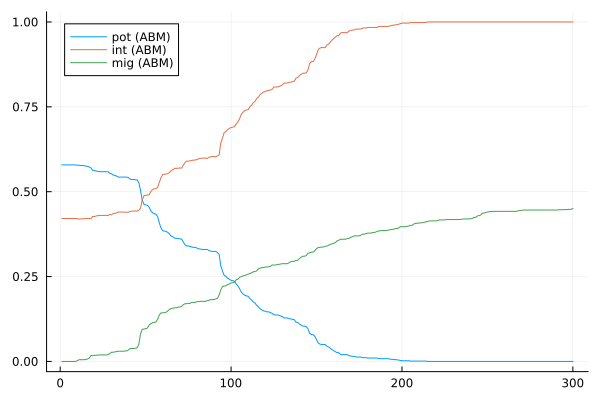

In [6]:
Plots.plot([pot, int, mig], labels = ["pot (ABM)" "int (ABM)" "mig (ABM)"])